# Variable-mean noise: LN models across a luminance step

**The experiment.** `VariableMeanNoise` delivers Gaussian noise of constant contrast **through
an LED** while the mean light level steps periodically. One epoch therefore contains steps in
both directions, and the question is how the cell's linear-nonlinear model changes as it adapts
to each new mean.

The protocol lives in two packages —
`edu.washington.riekelab.rieke.protocols.VariableMeanNoise` and
`edu.washington.riekelab.turner.protocols.VariableMeanNoise` — and they are the same protocol:
the recorded epoch parameters are identical, verified against the stored epochs rather than
assumed. Both are searched together and `protocol_name` says which one a block came from.


Model fitting is **cascadegraph**, vendored at `retinanalysis.utils.cascadegraph` — the Python
port of the library the MATLAB used. Nothing here reimplements a filter or a sigmoid.

In [1]:
import contextlib
import io
import json
import sys
import time
from pathlib import Path

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc

# The analysis module sits beside this notebook: it is specific to this project.
sys.path.insert(0, str(Path.cwd()))
import variable_mean_noise as vmn

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.80 s


### 1a. Recording type per block

These blocks carry no `onlineAnalysis`, so the amplifier decides. The epoch group's
`recordingTechnique` settles most of them; where it does not, series resistance above zero means
whole-cell with the polarity from the sign of the current (inward is `exc`, outward `inh`), and a
reading of exactly zero is confirmed against the trace, since it also happens when compensation
was never run.

Resolving a block that needs its trace is seconds per block, so this is **cached** to
`block_modes.csv` beside the notebook. Set `REFRESH_MODE_CACHE = True` to rebuild it (a few
minutes over ~400 blocks); otherwise it is read from disk.

In [3]:
REFRESH_MODE_CACHE = False

protocol_blocks = vmn.find_blocks(show=True, height=0)

block_modes = vmn.load_block_modes()
if REFRESH_MODE_CACHE or block_modes.empty:
    print(f'\nbuilding {vmn.MODE_CACHE_PATH.name} — a few minutes ...')
    block_modes = vmn.build_mode_cache(protocol_blocks)

print(f'\nrecording types over {len(block_modes)} cached blocks:')
print(block_modes.rec_type.value_counts(dropna=False).to_string())

protocol_cells = vmn.find_protocol_cells(protocol_blocks, modes=block_modes,
                                        show=True, height=460)


373 blocks | 46 experiments | 182 cells
  dropped 1227 block(s) with stimTime < 30 s
  dropped 120 block(s) on non-primate-RGC cell types
  by protocol: edu.washington.riekelab.rieke.protocols.VariableMeanNoise 262, edu.washington.riekelab.turner.protocols.VariableMeanNoise 111


exp_name,cell_label,cell_type_short,block_id,stim_seconds,led,ndfs,frequencyCutoff,numberOfFilters,Contrast,n_epochs,protocol_name
2020-06-11_B,Cell10,ON-parasol,30238,30,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30209,60,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,2,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30210,60,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,20,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell12,OFF-parasol,30188,30,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,15,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30174,30,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,19,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30177,30,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,6,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30216,30,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30218,30,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,27,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30318,60,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,10,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30319,30,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,11,edu.washington.riekelab.rieke.protocols.VariableMeanNoise



recording types over 373 cached blocks:
rec_type
extracellular    219
exc               78
NaN               76
125 cells across 35 experiments
  dropped 54 cell(s) that ran only one light mean
  dropped 3 cell(s) that ran more than one contrast


exp_name,cell_index,cell_label,cell_type,n_extracellular,n_exc,n_inh,light_means,light_contrast,stim_seconds,led
2020-06-11_B,0,Cell10,ON-parasol,0,14,0,"0.3, 3",0.5,30,UV LED
,1,Cell11,ON-midget,0,22,0,"0.3, 3",0.5,60,UV LED
,2,Cell12,OFF-parasol,15,0,0,"0.3, 3",0.5,30,UV LED
,3,Cell13,ON-parasol,19,6,0,"0.3, 3",0.5,30,UV LED
,4,Cell14,ON-parasol,14,27,0,"0.3, 3",0.5,30,UV LED
2020-06-16_B,5,Cell3,ON-parasol,21,53,0,"0.08, 0.3, 0.8, 3",0.5,"30, 60",UV LED
2020-06-23_B,6,Cell10,OFF-parasol,10,0,0,"0.3, 3",0.5,30,UV LED
,7,Cell8,ON-midget,20,0,0,"0.1, 1",0.5,30,UV LED
2021-02-01_B,8,cell1,ON-parasol,62,0,0,"0.05, 0.08, 0.5, 1, 5",0.5,30,UV LED
,9,cell2,ON-midget,31,0,0,"0.05, 0.5, 5",0.5,30,UV LED


## 2. Select one cell and inspect the raw data

Choose only the cell. Recording mode is classified automatically per block (`Rs == 0` extracellular;
positive `Rs` whole-cell, with mean-trace sign separating exc/inh), then every recorded `stimTime` is
discovered from every epoch. Paired conditions with fewer than
`MIN_EPOCHS_PER_CONDITION` epochs within the same recording type and duration are shown in the audit and excluded; no condition is silently
pooled with or truncated to another. Continue to §3 only after accepting the raw data.


2021-02-01_B | cell1 (ON-parasol) | UV LED | lightMean 0.05, 0.08, 0.5, 1, 5 | contrast 0.5 | 30 s
epochs: 62 extracellular, 0 exc, 0 inh
1 recording-mode x epoch-duration condition(s); 1 meet MIN_EPOCHS=6
     rec_type  stim_time_ms  stim_seconds  n_epochs           light_means                    epochs_by_light_mean  n_blocks  included reason
extracellular       30000.0          30.0        62 0.05, 0.08, 0.5, 1, 5 0.05: 10, 0.08: 6, 0.5: 22, 1: 6, 5: 18         2      True       

raw inspection: extracellular | 30 s | 62 epochs | blocks [11401, 11402]


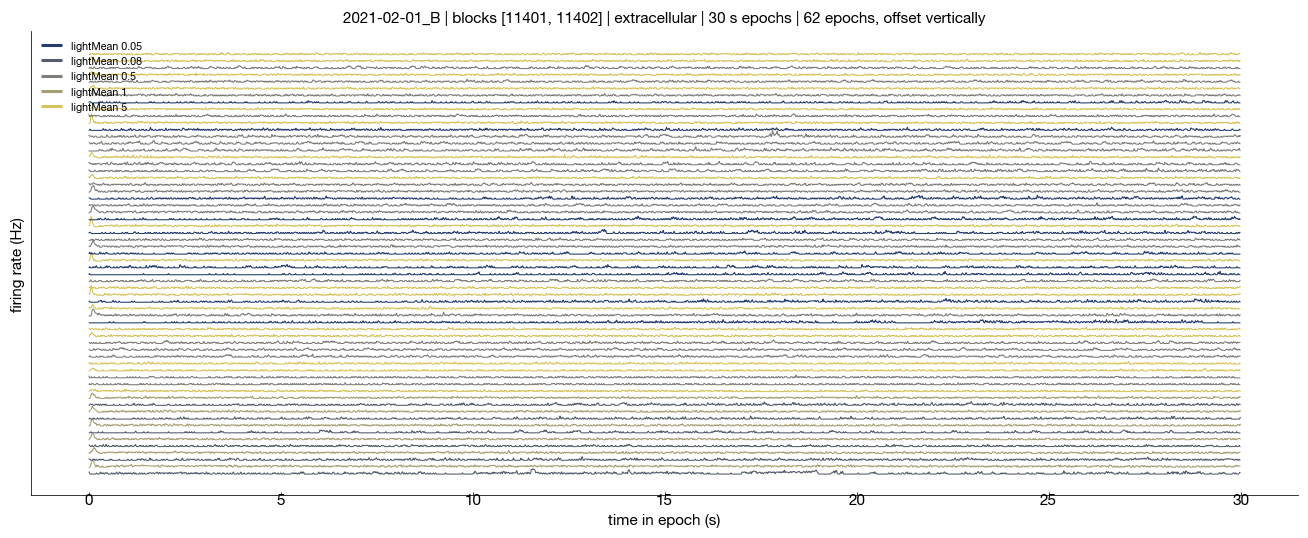

In [4]:
CELL_INDEX = 8
MAX_EPOCHS = None      # None shows/uses every epoch within each duration
MIN_EPOCHS_PER_CONDITION = 6  # required per recording type x duration

row = protocol_cells[protocol_cells.cell_index.eq(CELL_INDEX)].iloc[0]
print(f'{row.exp_name} | {row.cell_label} ({row.cell_type}) | {row.led} | '
      f'lightMean {row.light_means} | contrast {row.light_contrast} | '
      f'{row.stim_seconds} s')
print(f'epochs: {row.n_extracellular} extracellular, {row.n_exc} exc, {row.n_inh} inh')

EXP_NAME = row.exp_name
BLOCK_IDS = list(row._block_ids)
condition_table = vmn.recording_duration_conditions(
    BLOCK_IDS, modes=block_modes,
    min_epochs=MIN_EPOCHS_PER_CONDITION, show=True)
analysis_conditions = condition_table[condition_table.included].copy()
if analysis_conditions.empty:
    raise ValueError('No recording-type x duration condition meets the minimum epoch count')

raw_trace_figures = {}
for condition in analysis_conditions.itertuples():
    key = (condition.rec_type, float(condition.stim_time_ms))
    print(f'\nraw inspection: {condition.rec_type} | {condition.stim_seconds:g} s | '
          f'{condition.n_epochs} epochs | blocks {condition.block_ids}')
    raw_trace_figures[key] = vmn.plot_traces(
        EXP_NAME, condition.block_ids, condition.rec_type, max_epochs=MAX_EPOCHS,
        stim_time_ms=condition.stim_time_ms)


## 3. Run the mean response, static LN, and temporal LN analyses

One execution runs every recording-type × duration condition retained in §2 independently. For each condition, the
utility loads the responses, applies recording-specific QC, plots the group mean **before fitting**, fits the static LN
model, then fits the temporal LN models from exactly the same accepted arrays. Temporal windows are
data-adaptive when `TEMPORAL_WINDOW_S = None`, so that duration's usable epoch is covered without a
discarded remainder. For extracellular conditions, analysis stops with `LOW RESPONSE CELL` when
at least `LOW_RATE_EPOCH_FRACTION` of accepted epochs have a mean firing rate below
`MIN_FIRING_RATE_HZ`; both thresholds are explicit controls in the next cell.

`core_by_condition` keeps every table and figure keyed by `(recording type, stimTime)` so incompatible signals and durations never mix.
Stimulus reconstruction, saving, and the slow one-/two-state LNK fits remain separate decisions.


In [ ]:
# Shared loading and fit controls for the complete core analysis.
SKIP_SECONDS = 1.0          # omit the initial settling interval
DOWNSAMPLE = 10             # 10 kHz -> 1 kHz by block average
MEAN_WINDOW_S = 2.0         # group-mean response averaging window
WINDOW_SECONDS = 6.0        # displayed measured/predicted trace length
TEMPORAL_WINDOW_S = None    # adaptive equal windows spanning the usable epoch

# Extracellular-only response QC; both values are editable policy parameters.
MIN_FIRING_RATE_HZ = 2.0
LOW_RATE_EPOCH_FRACTION = 0.70

# Whole-cell-only QC; ignored automatically for extracellular recordings.
MAX_SERIES_RESISTANCE = 30e6
ALIGN_EPOCH_MEANS = True

core_by_condition = {}
for condition in analysis_conditions.itertuples():
    rec_type = condition.rec_type
    duration = float(condition.stim_time_ms)
    key = (rec_type, duration)
    print(f'\n=== {rec_type} | {condition.stim_seconds:g} s epochs | '
          f'{condition.n_epochs} recorded ===')
    core = vmn.run_core_ln_analysis(
        EXP_NAME, condition.block_ids, rec_type=rec_type,
        stim_time_ms=duration, skip_seconds=SKIP_SECONDS,
        downsample=DOWNSAMPLE, max_epochs=MAX_EPOCHS,
        max_series_resistance=MAX_SERIES_RESISTANCE,
        align_epoch_means=ALIGN_EPOCH_MEANS,
        min_firing_rate_hz=MIN_FIRING_RATE_HZ,
        low_rate_epoch_fraction=LOW_RATE_EPOCH_FRACTION,
        mean_window_s=MEAN_WINDOW_S,
        condition_window_s=WINDOW_SECONDS,
        temporal_window_s=TEMPORAL_WINDOW_S, verbose=True)
    core_by_condition[key] = core
    if len(core.analysis.dropped_epochs):
        display(core.analysis.dropped_epochs)
    if len(core.analysis.epoch_adjustments):
        display(core.analysis.epoch_adjustments.round(1))
    shown = core.summary.copy()
    shown.insert(0, 'stim_seconds', duration / 1e3)
    display(shown.round(3))


## 4. Reconstruct the light from the response

The LN model says how the light drives the cell. This is the reverse: **reconstruct the stimulus
trace from the response alone**, then ask how good that reconstruction is — separately while the
light is above its mean (increment phase) and below it (decrement phase).

A linear decoding filter is fitted from response onto stimulus and applied to a held-out epoch.
No classifier and no thresholding: the output is a light trace in stimulus units, compared with
the real one sample by sample. Reconstruction can fail in three ways, so all three are reported
per phase:

- **`r`** — correlation with the stimulus: right shape and timing, regardless of scale.
- **`gain`** — through-origin slope of reconstruction on stimulus. 1.0 recovers the true
  amplitude; below 1 is compressed. Correlation cannot see this — a perfectly shaped
  reconstruction at half amplitude still has `r = 1`, and compression is exactly what adaptation
  produces.
- **`nrmse`** — error over the phase, divided by the *overall* stimulus SD so both phases sit on
  one scale.

**Two train/test regimes**, and the comparison is what shows the adaptation:

- **refitted each window** — decoder fitted inside the window, reconstruction scored on a
  held-out epoch of it. How well the response supports reconstruction at that moment.
- **fitted on the adapted state** — one decoder fitted on the last `STEADY_STATE_S`, applied to
  earlier windows it never saw (overlapping windows are refused, not assumed disjoint). What a
  reader with a fixed, adapted decoder recovers from the un-adapted response.

**Two figures carry what the three numbers cannot.** The transfer function plots the
reconstruction against the true stimulus, so the phase split *is* the x axis — left of zero is
the decrement phase, right of it the increment phase — and a side that falls below the identity
line is a compressed phase. That says **where in stimulus space** accuracy is lost: a uniform
gain difference and a saturation that only bites at large excursions look completely different
on it. The phase-onset triggered average aligns on every zero crossing and averages, which says
**when within a phase** it is lost: a reconstruction that catches the onset and then decays is
not the same failure as one that is uniformly small.

Conditioning on the sign of the true stimulus restricts its range within each phase, which
lowers `r` relative to the unconditioned value. The stimulus is symmetric, so it lowers both
phases identically and the increment-versus-decrement comparison stays fair; the `_all` columns
are there so the absolute level is not read off a conditioned number.

**Why these time scales are used.** They have different jobs and should not be interpreted as
interchangeable smoothing parameters:

- **`DECODE_SKIP_S = 1 s`** excludes the immediate mean-light step transient. This is a biological
  analysis boundary, not a parameter that prediction can optimize: set it to 0 only when the
  question includes onset, and then interpret the first window as onset plus adaptation.
- **`DECODE_WINDOW_S = 'auto'`** selects the time-local *fit/scoring interval* independently for
  each recording condition. Candidate widths from 1--5 s are compared using leave-one-epoch-out
  stimulus reconstruction. Correlations are Fisher transformed, and the shortest window within
  one standard error of the best held-out score is chosen. This is preferable to simply taking the
  maximum: among statistically equivalent decoders it preserves the temporal resolution needed to
  see 1--3 s recovery. The diagnostic table shows every candidate, the realized exactly tiled width,
  its held-out score, and the selected row. One second remains the enforced floor
  (`vmn.MIN_DECODE_WINDOW_S`).
- **`DECODE_BIN_MS = 20 ms`** is only the resolution at which reconstructed and true stimulus
  traces are compared and displayed; it is not a second fitting window and is therefore not selected
  by decoder cross-validation. It suppresses sample-scale response noise while remaining near the
  response-filter time scale.
- **`STEADY_STATE_S = 10 s`** reserves the final 10 s to estimate one fully adapted decoder. Any
  application window that overlaps those training data is rejected, preventing train/test leakage.
  For a 30-s stimulus with a 1-s skip, this leaves only about the preceding 19 s for the
  steady-state-decoder trajectory.
- **`MIN_PHASE_MS = 2 * DECODE_BIN_MS`** requires an increment or decrement excursion to persist
  for at least two displayed bins before it enters the phase-triggered average. This retains short
  excursions and more events, but is more sensitive to noisy zero crossings; 100 ms is the
  stricter alternative
  when the goal is a sustained-phase average. Each accepted crossing is displayed from 100 ms
  before to 300 ms after onset, which supplies a short baseline and covers the decoder/filter
  response without changing any fit.
- **`TRACE_SECONDS = (10, 15)`** selects a readable 5-s example from the middle record, after
  the excluded onset. It affects only the raw-trace figure, never a fit or summary metric.


In [ ]:
DECODE_SKIP_S = 1.0      # exclude the onset/settling transient
DECODE_WINDOW_S = 'auto'
DECODE_WINDOW_CANDIDATES_S = (1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0)
DECODE_BIN_MS = 20.0     # near the filter width; 1 ms bins are mostly noise
STEADY_STATE_S = 10.0    # trailing stretch used as the adapted decoder
MIN_PHASE_MS = 2 * DECODE_BIN_MS  # require at least two displayed bins
TRACE_SECONDS = (10.0, 15.0)

# Each recording-type/duration condition is reloaded and reconstructed independently.
reconstruction_by_condition = {}
for (rec_type, duration), core in core_by_condition.items():
    print(f'\n=== reconstruction | {rec_type} | {duration / 1e3:g} s epochs ===')
    decode_analysis = vmn.analyze_condition(
        EXP_NAME, core.analysis.block_ids, rec_type=rec_type,
        stim_time_ms=duration, skip_seconds=DECODE_SKIP_S,
        downsample=DOWNSAMPLE, max_epochs=MAX_EPOCHS,
        max_series_resistance=MAX_SERIES_RESISTANCE,
        align_epoch_means=ALIGN_EPOCH_MEANS, fit=False, verbose=False)
    if DECODE_WINDOW_S == 'auto':
        decode_window_s, window_selection = vmn.select_decode_window(
            decode_analysis, candidates_s=DECODE_WINDOW_CANDIDATES_S,
            decode_bin_ms=DECODE_BIN_MS, verbose=True)
    else:
        decode_window_s = float(DECODE_WINDOW_S)
        window_selection = pd.DataFrame()
    if not window_selection.empty:
        display(window_selection.drop(columns='mean_fisher_z').round(3))
    trace_figure = vmn.plot_reconstruction_trace(
        decode_analysis, seconds=TRACE_SECONDS, decode_bin_ms=DECODE_BIN_MS)
    traces = pd.concat(
        [vmn.reconstruct_traces(
            decode_analysis, mode=mode, window_seconds=decode_window_s,
            decode_bin_ms=DECODE_BIN_MS, steady_state_s=STEADY_STATE_S,
            verbose=True)
         for mode in ('per_window', 'steady_state')], ignore_index=True)
    transfer_figure = vmn.plot_reconstruction_transfer(decode_analysis, traces)
    phase_figure = vmn.plot_phase_triggered(
        decode_analysis, traces, min_phase_ms=MIN_PHASE_MS)
    decoded = vmn.decode_recovery(
        decode_analysis, window_seconds=decode_window_s,
        decode_bin_ms=DECODE_BIN_MS, steady_state_s=STEADY_STATE_S,
        verbose=True)
    decoding_figure = vmn.plot_decoding(decode_analysis, decoded)
    reconstruction_by_condition[(rec_type, duration)] = {
        'analysis': decode_analysis, 'decode_window_s': decode_window_s,
        'window_selection': window_selection, 'traces': traces, 'decoded': decoded,
        'trace_figure': trace_figure, 'transfer_figure': transfer_figure,
        'phase_figure': phase_figure, 'decoding_figure': decoding_figure}
    shown = vmn.reconstruction_summary(decoded)
    shown.insert(0, 'stim_seconds', duration / 1e3)
    display(shown.round(3))


### 4a. Transfer function: early against late

The transfer function above **pools every window**, so the curve it draws is a mixture of the
un-adapted and the adapted response. That matters here rather than being a technicality:
`r_gain` in the summary says reconstruction really does improve over the epoch, so the mixture
is not a small one, and a curve that bends could be bending because the cell saturates or only
because the first second after the step is averaged in with the tenth.

Splitting the same traces by time since the step separates the two. Three readings, and they are
different claims:

- **the slope shifts between halves** — the gain the decoder recovers changes as the cell adapts;
- **the curve leaves the straight part at a different place** — the *saturating range* moves,
  which is a change in what the cell can still signal, not in what it multiplies by;
- **the two curves lie on top of each other** — the compression was there from the first second
  and is a property of the cell at that light level, not the adaptation. A negative result, and
  the one the pooled figure cannot give.

**The cut points are taken per (regime × light mean), not globally.** The two decoding regimes do
not cover the same windows: the steady-state decoder refuses every window it was fitted on, so
its last window ends `STEADY_STATE_S` before the epoch does. One global cut would compare that
regime's *middle* against the other's *end* and report the difference as adaptation. `span_s` and
`t_start_s` in the table record what each half actually covers, so this is checkable rather than
promised.

**Read the earliest window knowing what is in it.** Each decoding window is mean-subtracted,
which removes the step's sustained offset but not the transient inside the first window, and that
transient is response the stimulus in that window did not cause. It inflates the apparent noise
early — visible as a wider band — but it is not a reason for a *slope* to differ.

**The halves are adaptive rather than fixed-duration.** For each `(regime × light mean)`, the
available interval starts after `DECODE_SKIP_S` and is divided at its midpoint: samples at or
before the midpoint are early and samples after it are late. Thus a 30-s epoch with a 1-s skip
gives two approximately 14.5-s halves for the per-window decoder. The steady-state decoder has a
shorter available interval because its final training segment is excluded, so that interval is
split independently into equal halves. `split_s`, `t_start_s`, and `t_end_s` expose the actual
boundaries in the table; no epoch-duration constants need to be updated for a new protocol.

Both halves are binned on one x grid, taken over the whole panel rather than per half, so the
curves are comparable point for point. Bins holding fewer than `min_count` samples are left as
gaps: the tails are exactly where a saturation shows up, and a curve drawn there from eight
points would invent one. The raw density is deliberately not redrawn — two overlaid hexbins are
unreadable, and the scatter is in the pooled figure above.



=== early vs late | extracellular | 30 s epochs ===


,stim_seconds,mode,lightMean,half,split_s,t_start_s,t_end_s,span_s,n_bins,gain_increment,gain_decrement,gain_asymmetry,r_increment,r_decrement,r_all
0,30.0,per_window,0.1,early,15.5,1.01,15.49,14.48,7250,0.391,0.329,0.062,0.371,0.281,0.545
1,30.0,per_window,0.1,late,15.5,15.51,29.99,14.48,7250,0.379,0.333,0.046,0.363,0.273,0.542
2,30.0,per_window,1.0,early,15.5,1.01,15.49,14.48,7250,0.366,0.440,-0.073,0.218,0.420,0.588
3,30.0,per_window,1.0,late,15.5,15.51,29.99,14.48,7250,0.379,0.448,-0.069,0.243,0.434,0.598
4,30.0,steady_state,0.1,early,10.5,1.01,10.49,9.48,4750,0.381,0.324,0.058,0.377,0.282,0.543
5,30.0,steady_state,0.1,late,10.5,10.51,19.99,9.48,4750,0.387,0.352,0.035,0.329,0.301,0.548
6,30.0,steady_state,1.0,early,10.5,1.01,10.49,9.48,4750,0.392,0.494,-0.102,0.215,0.477,0.604
7,30.0,steady_state,1.0,late,10.5,10.51,19.99,9.48,4750,0.406,0.455,-0.049,0.262,0.400,0.599


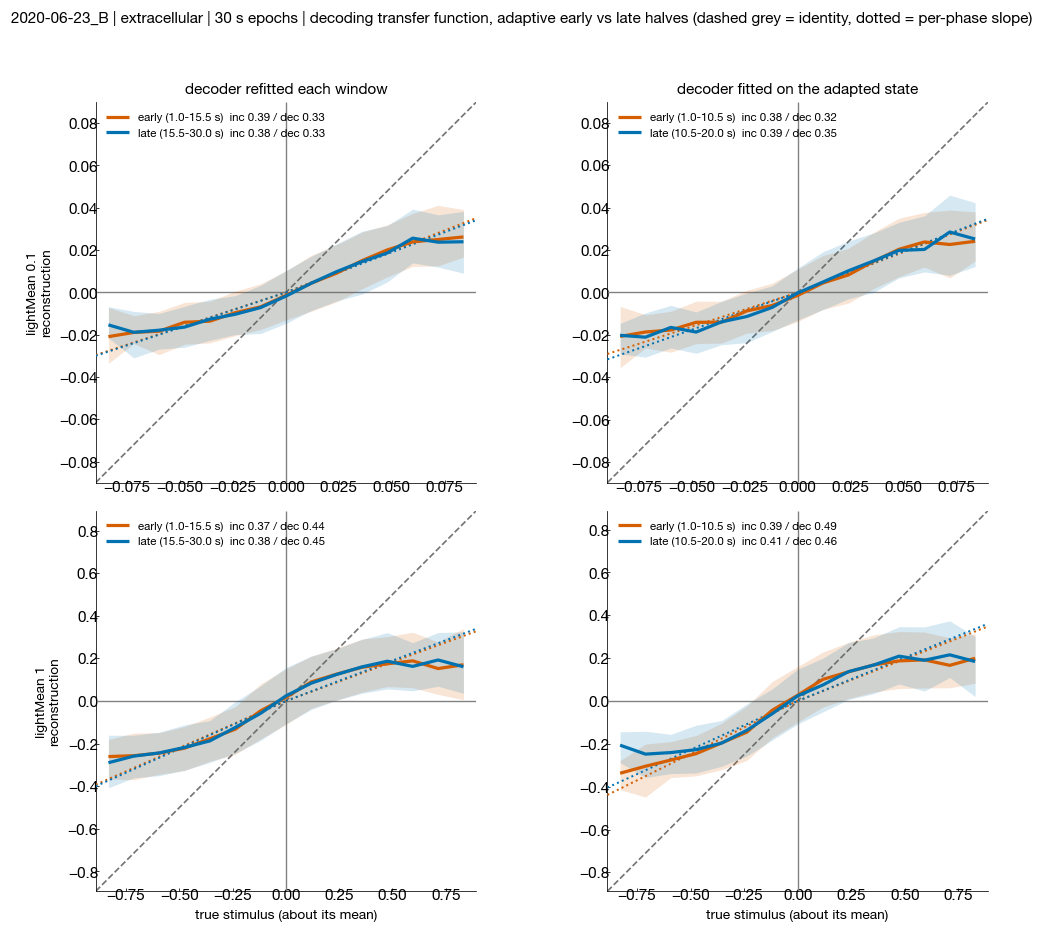

In [31]:
# Split and plot each condition's own reconstructed interval.
for (rec_type, duration), result in reconstruction_by_condition.items():
    print(f'\n=== early vs late | {rec_type} | {duration / 1e3:g} s epochs ===')
    early_late = vmn.transfer_early_late(result['traces'])
    result['early_late'] = early_late
    shown = early_late.copy()
    shown.insert(0, 'stim_seconds', duration / 1e3)
    display(shown[['stim_seconds', 'mode', 'lightMean', 'half', 'split_s',
                   't_start_s', 't_end_s', 'span_s', 'n_bins',
                   'gain_increment', 'gain_decrement', 'gain_asymmetry',
                   'r_increment', 'r_decrement', 'r_all']].round(3))
    result['early_late_figure'] = vmn.plot_transfer_early_late(
        result['analysis'], result['traces'])


## 5. Save this cell for population analysis

Save one compressed HDF5 record for every retained cell × recording mode × epoch-duration condition. The
record contains cell identity, rig, the **selected LED's own NDF stack** and attenuation, and
the reusable outputs from §3–4: mean response, static and temporal LN summaries and curves,
decoding windows and summary, and early/late transfer metrics. The FilterWheel is retained only
as ignored provenance because this LED does not pass through it.

The single-state and double-state LNK results are deliberately not saved. This cell therefore
does not depend on either slow section below. `save_condition_outputs` writes all retained mode-duration pairs automatically.
The recorded `stim_time_ms`/`stim_seconds` is stored in each file and included in its filename, so rerunning
the same duration replaces that file atomically while a different duration remains a separate entity.


In [32]:
saved_condition_outputs = vmn.save_condition_outputs(
    core_by_condition, protocol_blocks,
    reconstruction_by_condition=reconstruction_by_condition,
    mean_window_s=MEAN_WINDOW_S)
display(saved_condition_outputs)


saved Cell8 (ON-midget, extracellular) | rig two_photon | 30 s epochs | UV LED | LED NDF (none)
/Users/chrischen/Documents/GitHub/retinanalysis/SingCellNotebooks/rodAdaptation/condition_outputs/2020-06-23_B__Cell8__extracellular__duration-30000ms__blocks-8bb5e3c287.h5 | LNK outputs excluded


,rec_type,stim_time_ms,stim_seconds,n_epochs,output_path
0,extracellular,30000.0,30.0,20,/Users/chrischen/Documents/GitHub/retinanalysi...


### 5a. Check saved cells

Read only the small HDF5 attributes, without loading model curves or result tables. This is the
quick audit of date, cell label/type, recording mode, **epoch duration**, epoch count, rig, LED,
and the LED-specific NDF stack. Legacy files written before duration separation show a blank duration.


In [2]:
saved_cells = vmn.load_condition_index()
print(f'{len(saved_cells)} saved cell condition(s)')
sc.scroll_table(
    saved_cells[['output_version', 'date', 'cell_label', 'cell_type', 'rec_type',
                 'stim_seconds', 'n_epochs_total', 'rig', 'led', 'led_ndfs',
                 'optical_density', 'n_blocks']],
    height=300, num_cols=('stim_seconds', 'n_epochs_total', 'optical_density',
                          'n_blocks'))


10 saved cell condition(s)


output_version,date,cell_label,cell_type,rec_type,stim_seconds,n_epochs_total,rig,led,led_ndfs,optical_density,n_blocks
1,2020-06-11_B,Cell10,ON-parasol,exc,,0,two_photon,UV LED,B4,2.54,1
1,2020-06-11_B,Cell12,OFF-parasol,extracellular,,0,two_photon,UV LED,B4,2.54,1
1,2020-06-11_B,Cell13,ON-parasol,extracellular,,0,two_photon,UV LED,B4,2.54,1
1,2020-06-11_B,Cell14,ON-parasol,exc,,0,two_photon,UV LED,B4,2.54,1
1,2020-06-11_B,Cell14,ON-parasol,extracellular,,0,two_photon,UV LED,B4,2.54,1
2,2020-06-16_B,Cell3,ON-parasol,exc,30.0,53,two_photon,UV LED,B4,2.54,6
2,2020-06-16_B,Cell3,ON-parasol,extracellular,30.0,11,two_photon,UV LED,B4,2.54,1
2,2020-06-16_B,Cell3,ON-parasol,extracellular,60.0,10,two_photon,UV LED,B4,2.54,1
2,2020-06-23_B,Cell10,OFF-parasol,extracellular,30.0,10,two_photon,UV LED,(none),0.0,1
2,2020-06-23_B,Cell8,ON-midget,extracellular,30.0,20,two_photon,UV LED,(none),0.0,2


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:300px"><table><thead><tr><th>output_version</th><th>date</th><th>cell_label</th><th>cell_type</th><th>rec_type</th><th>stim_seconds</th><th>n_epochs_total</th><th>rig</th><th>led</th><th>led_ndfs</th><th>optical_density</th><th>n_blocks</th></tr>

## 6a. LNK variant A — one slow state, coupling **imposed**

> **§6a and §6b are alternatives and each runs on its own.** Both need only
> `decode_analysis` from §4, not each other, so run either, both, or neither. Each has a
> `RUN_...` switch at the top of its cell. On the cached example A now takes about 25 s;
> B remains the several-minute fit.
>
> **A (this section)** *imposes* the adaptation — a slow state either rescales or shifts the
> nonlinearity, and the fit reports which fits better.
> **B (§6b)** imposes nothing — the kinetics block is the output stage and any change in the
> nonlinearity has to *emerge* from depletion, so the shift-or-scale answer becomes a
> prediction rather than an input.

Everything above fits a *separate* filter and nonlinearity per light mean, and per window within
it. That describes the adaptation but does not explain it. This fits **one** filter and **one**
nonlinearity across the whole recording and gives them a single slow state to move — the
reduction of Ozuysal & Baccus's LNK that our own data licenses.

**Why only the slow part.** The full LNK has four kinetic states, two of them there to reproduce
the fast change in temporal filtering that follows a contrast step. Our filters do not do that:
§3 shows time-to-peak constant to a millisecond or two across nine windows spanning 30 s.
Fitting four fast parameters to a flat line is how identifiability problems start. One slow
state leaves 7 free parameters against 570 s at 1 kHz, instead of 26.

**Two couplings, and the comparison is the experiment.** The state returns to the nonlinearity
one of two ways:

- `multiplicative` — `r = α·exp(−k·a′)·Φ(βg + γ) + ε` — changes the **slope**
- `subtractive` — `r = α·Φ(βg + γ − k·a′) + ε` — **shifts** the curve

A gain-only mechanism *cannot* produce a shift: scaling a rectifying nonlinearity compresses it
toward zero, it does not translate it. So these are two mechanisms, not two settings of one, and
which a cell needs is a model comparison with a held-out likelihood behind it — the form the
midget-shifts/parasol-scales hypothesis has to take to be testable.

**One filter per light mean.** LNK itself carries a single filter, but what its kinetics block
does to the gain is a *scaling* — the supplement's eq 18 gives instantaneous gain ∝ the
resting-state occupancy `R(t)`, which multiplies the nonlinearity's output and leaves its input
alone. The block does also change its own impulse response with mean drive, but that runs through
the **fast** rate constants (their Fig. 7, and Fig. 8C–D makes the time-constant change a
function of `kfi/ka` and `kfr/ka`).

This reduction keeps only the slow state, so it has no way to restructure a filter whose
time-to-peak is 32 ms at one light level and 59 ms at the other — a seconds-timescale state
cannot do that whichever way it couples. The per-level filter difference therefore has to be
supplied rather than generated. Held-out r² on this cell:

| filter | unweighted | weighted |
|---|---|---|
| shared | 0.338 | 0.153 |
| per light mean | 0.766 | 0.746 |

A shared filter fails under either error metric, as it must: it asks one filter to stand in for
two that correlate only 0.71 with each other, with nothing in the model able to reconcile them.
`filter_mode='shared'` reproduces that comparison.

Each filter is normalised to **shape only**. That is load-bearing: `compute_filter` also returns
a gain, and its gain is inversely proportional to the stimulus amplitude, so keeping it would
equalise the generator across light levels and leave the state with no luminance signal at all.
Stripped to shape, the generator's SD follows the stimulus — 9.8× larger when bright — which is
the "mean of a rectified signal" the state adapts to.

The nonlinearity and the state stay **shared** across levels, parameterised identically. That is
the claim being tested: what changes within an epoch is one slow process acting on one fixed
nonlinearity.

**The filter is five parameters.** Each level's reverse-correlation estimate is reduced to
cascadegraph's `ParamFilterNode` form — a rising saturation × exponential decay × cosine — by
`vmn.fit_param_filter`, replacing ~1000 samples with 5 numbers at a cost of 0.005 held-out r²
(shape r² 0.987–0.993 here). The starts are scaled to each filter's own time-to-peak, which is
essential: with time constants fixed at fast values the same form fits a 32 ms filter at r² 0.99
and a 200 ms one at r² ≈ 0. That looks like the form failing when it is only badly started.

`fit_filter=True` puts those 5 per level into the joint search, as `baccuslab/LNKS` does with its
8 basis coefficients, on the grounds that `F_LNK` ≠ `F_LN`. Measured here it buys nothing:
frozen 0.761 held out vs fitted 0.758, while in-sample moves the other way (0.654 → 0.663) — ten
extra parameters bought training fit and lost a little generalisation, at 5× the runtime. One
cell and one split, and 0.003 is inside the noise, so read it as "no measurable benefit", not
"freezing is better". Off by default on cost.

**One architectural departure, stated plainly.** In LNKS the kinetics block *is* the output stage
(`v = X[1,:]`, the active-state occupancy, min-max normalised) and the nonlinearity only supplies
its drive — which is why 2 nonlinearity parameters suffice there and 4 are needed here. In this
reduction the nonlinearity is the output stage and the slow state modulates it. That follows from
dropping the fast states: in LNK the block is simultaneously the fast output stage and the slow
adaptation mechanism, so keeping only the slow half leaves nothing to generate the response.

So this is a **phenomenological** model of the observed nonlinearity change — it imposes a slope
change or a shift and asks which fits better — not a mechanistic one that derives either from
depletion. A two-state variant (one fast output state, one slow adaptive state) would restore the
LNK architecture and let the change emerge rather than be imposed; that is §6b.

**Initialisation follows the supplement.** The filter shapes and sigmoid parameters are taken
directly from §3's stored static LN models (the brightest mean supplies the shared sigmoid),
with `beta` transformed onto the LNK generator scale. This is not a second approximate LN fit.
One deterministic start is the default because it reaches the same optimum as two on the checked
cell; `n_restarts` remains available when diagnostics suggest another basin. Time constants are
searched in log space, between the native integration interval and the analysed recording
duration, so positivity and bounds come from the data rather than fixed 0.05–60 s constants.
The five-parameter filter fit now uses two data-scaled deterministic starts and adds seeded
starts only until its shape fit is adequate; the old code always ran 40. Both coupling models
reuse that same prepared generator. Profiling showed these filter starts — not state integration
— dominated runtime, so compiled C code would add complexity without addressing the bottleneck.

**Response units are carried by the data.** The sigmoid detects rising versus falling responses,
so extracellular rates and negative-going whole-cell currents use the same equations. `epsilon`
is bounded around the observed holding level rather than around zero. The extracellular amplitude
guard remains 1000 Hz for the observed 0–500 Hz range; whole-cell bounds expand from the observed
current span when a trace exceeds the nominal 8 nA guard (for example −10 nA to +1 nA). LNK's
least-squares scaling is taken from its Jacobian so pA-valued amplitudes, second-valued kinetics,
and dimensionless coupling parameters can be optimized together.

`weighted=True` reproduces their error metric (eq 27): residuals normalised within 10 s time bins
and two frequency bands, so a high-amplitude stretch cannot dominate. Off by default because `r²`
is reported unweighted and mixing the two makes it hard to read — and because our imbalance is
milder than theirs, the stimulus differing 10× between levels but the spike rate only about 2×.

**What makes the fit sound.** The epochs are concatenated in *recorded* order, which alternates
light means; `interpulseInterval = 0`, so that is one continuous 570 s record. The state is
driven by the stimulus alone and never by the measured response, so it can be integrated across
held-out epochs without leaking. The first epoch is integrated but excluded from fitting and
scoring, so the forced initial state `a0 = 0` is warm-up rather than data. Integration uses the
native sample grid by default. `a′` is standardised — its mean is degenerate with `α`/`γ` and
its scale with the time constants, so only `k`, the modulation per SD of adaptation, is
identifiable.

**Read `r²` against `r2_static`, not against §3.** The static baseline is this same cascade with
`k = 0` and its nonlinearity refitted — nested, so `r2_gain` is what the state buys and nothing
else. The per-window LN r² from §3 is a much easier problem (a fresh filter and nonlinearity
every 3 s) and is not the comparison.

### One-state nonlinearity over time and filter stability

The point of the model is that **one** slow state moves **one** fixed nonlinearity, so "how the
nonlinearity changes" is not a separate fit per window — it is the same four parameters
(`alpha`, `beta`, `gamma`, `epsilon`) evaluated at the state the cell has reached by that time:

- `multiplicative` — `r(g) = α·exp(−k·a′)·Φ(βg + γ) + ε`
- `subtractive` — `r(g) = α·Φ(βg + γ − k·a′) + ε`

with `a′` the standardised state averaged over the window, the same standardisation the fit
applied. Windows are **geometric, not even**: the state moves fastest just after the step and
barely at all by the end, so even windows spend their resolution where nothing is happening.
Both fitted motifs are shown. Each figure explicitly draws the fixed `a′ = 0` LNK basis, the
state's conversion into `exp(−k·a′)` gain or `k·a′/β` generator shift, and the resulting
nonlinearity snapshots. The windows sample a continuous model trajectory for display; no
filter or nonlinearity is refitted within a window.

**Binning by time is why the measured curve is safe here.** §6b's `apparent_nonlinearity` has to
work analytically because splitting the record *on the state* is confounded — the state is driven
by the stimulus, so high-state samples are also high-drive samples and the split selects on the
very axis being plotted. That is what produced a gain ratio above 1 there, the opposite of what
depletion does. Time since the step is imposed by the protocol and is not selected by the
stimulus, so the dots (measured response binned on the generator within a window) are an honest
comparison rather than a circular one.

**The fourth column is the model's central assumption, drawn.** This reduction keeps only a
slow state, which cannot restructure a filter — so the filter is frozen per light mean and every
change within a level is charged to the nonlinearity. If §3's windowed filters move over the
epoch, that assumption is wrong for this cell and the third column is partly absorbing a filter
change. Those filters come from the fit on `analysis` (`SKIP_SECONDS = 1`), so their windows
start a second later than the LNK's; what is being compared is the **shape across windows**, not
the times.

**`warmup_epochs` is not cosmetic.** `adaptation_state` integrates from `a0 = 0`, and the state
is standardised before it is coupled — so a zero start is not a small perturbation but zero
against a record whose mean state is far from zero and whose spread may be small. On a synthetic
record with mean state 0.46 and SD 0.038 the opening samples sit at **−12 standardised units**
and `exp(−k·a′)` reaches 1530 against 46 for the rest of the record. That lands in the earliest
window, exactly the one this figure is about, so the first epoch is dropped by default. It is the
initial condition, not the cell's history — and it is worth knowing that the same samples are in
the residual `fit_lnk` minimises.


In [ ]:
RUN_ONE_STATE = True     # set False to skip this section

# Fitted on decode_analysis with the explicit DECODE_SKIP_S chosen in §4.
# Set that control to 0 there if the kinetic fit should include the onset transient.
LNK_STATE_DT_MS = None   # native sample grid; avoids biasing fitted kinetics
LNK_TEST_FRACTION = 0.2  # whole epochs held out of the residual
LNK_WARMUP_EPOCHS = 1    # integrate, but do not score the forced a0 = 0 epoch
LNK_RESTARTS = 1         # static-LN start; add restarts only if diagnostics warrant
LNK_VIEW_S = (25.0, 95.0)

NL_WINDOWS = 5           # geometric windows: fine early, where the state moves
NL_WARMUP_EPOCHS = 1     # see above -- the first epoch is the a0 = 0 start, not the cell

one_state_by_condition = {}
if RUN_ONE_STATE:
    for (rec_type, duration), reconstruction in reconstruction_by_condition.items():
        print(f'\n=== one-state LNK | {rec_type} | {duration / 1e3:g} s epochs ===')
        decode_analysis = reconstruction['analysis']
        core = core_by_condition[(rec_type, duration)]
        lnk_models = vmn.compare_lnk_couplings(
            decode_analysis, static_analysis=core.analysis,
            state_dt_ms=LNK_STATE_DT_MS, warmup_epochs=LNK_WARMUP_EPOCHS,
            n_restarts=LNK_RESTARTS, test_fraction=LNK_TEST_FRACTION,
            verbose=True)
        lnk_figure = vmn.plot_lnk_fit(
            decode_analysis, lnk_models, seconds=LNK_VIEW_S)
        display(vmn.lnk_summary(lnk_models).round(3))
        timelapse_by_coupling, timelapse_figures = {}, {}
        fitted = {name: model for name, model in lnk_models.items()
                  if model is not None}
        summaries = []
        for name, model in fitted.items():
            curves = vmn.nonlinearity_timelapse(
                decode_analysis, model, n_windows=NL_WINDOWS,
                warmup_epochs=NL_WARMUP_EPOCHS)
            timelapse_by_coupling[name] = curves
            summary_one = vmn.describe_timelapse(curves)
            if len(summary_one):
                summary_one.insert(0, 'coupling', name)
                summaries.append(summary_one)
            timelapse_figures[name] = vmn.plot_nonlinearity_timelapse(
                decode_analysis, model, curves,
                temporal_models=core.temporal_models,
                warmup_epochs=NL_WARMUP_EPOCHS)
        if summaries:
            display(pd.concat(summaries, ignore_index=True).round(3))
        best = max(fitted, key=lambda name: fitted[name].r2) if fitted else None
        if best is not None:
            print(f'preferred coupling by held-out r2: {best}')
        one_state_by_condition[(rec_type, duration)] = {
            'models': lnk_models, 'figure': lnk_figure,
            'timelapse_by_coupling': timelapse_by_coupling,
            'timelapse_figures': timelapse_figures, 'preferred': best}
else:
    print('skipped (RUN_ONE_STATE = False)')


## 6b. LNK variant B — fast output state + slow pool, coupling **emergent**

Variant A asks *which* change fits better by building both in. This one builds in neither. It
restores the reference architecture: in `baccuslab/LNKS` the kinetics block **is** the output
stage (`v = X[1,:]`, the active state), and the nonlinearity only supplies its drive. Three
occupancies of one pool, summing to 1:

$$\frac{dA}{dt} = k_{act}\,u\,(1 - A - I) - k_{inact}A \qquad
  \frac{dI}{dt} = k_{slow,in}A - k_{slow,out}I \qquad r = \alpha A + \varepsilon$$

Gain is proportional to the resting occupancy $R = 1 - A - I$ (supplement eq 18), so sustained
drive fills the slow pool $I$ at $R$'s expense and the cell adapts. Nothing here says *how* the
input–output curve should change, so **whichever it does is a prediction** —
`vmn.apparent_nonlinearity` reads it back off the fitted model, which is the analogue of the
paper's Fig. 3A.

**Eight free parameters** against variant A's seven: `alpha`/`epsilon` map occupancy into
response units, `beta`/`gamma` shape the drive, and four rate constants.

Three things worth knowing before reading the output:

- **The fast state is fitted as `tau_fast` and `occupancy`, not as two rate constants.** Only
  those combinations are identifiable. `k_act/k_inact` sets the active state's occupancy and
  their sum sets its speed, but past the sampling interval the sum stops mattering: scaling both
  by 20× holding the ratio moved held-out r² only 0.671 → 0.667 and left occupancy at 0.0555, so
  the optimiser drifted up that flat direction until `k_act` pinned at 2000/s. Changing the ratio
  alone has a real optimum. `tau_fast` is floored at the sampling interval — nothing faster is
  resolvable, and pushing well past it makes the relaxation underflow to NaN.

  **`tau_fast` then sits at that floor, and that is the result, not a defect.** The fast state
  wants to be instantaneous: the per-level temporal filter already carries all the fast dynamics,
  so the kinetics block has none left to contribute and reduces to an instantaneous rectification
  plus the slow pool. Whether the fast state earns its place is worth asking on other cells.
- **`alpha` is rate per unit occupancy, not a response range.** `A` peaks near 0.3–0.6, so the
  physiological ceiling is divided by that headroom or it binds for a units reason.
- **The integration marches, it does not iterate.** Each block solves `A` exactly with `I` fixed,
  then advances `I` from the block's mean `A`. An earlier sweep-the-whole-record scheme oscillated
  above `k_slow_in/k_slow_out ≈ 10`, which is where the data wants to go. Its error is block
  quantisation and falls with block size, which the tests check by refinement rather than by a
  chosen tolerance.

Read `r²` against `no depletion` — the same cascade with `k_slow_in = 0`, so the difference is
whether depletion is allowed at all. On 2020-06-11_B this scores 0.760 held out against variant
A's 0.761: the two architectures are equally good on this cell, and **neither is overfitting** —
both score higher held out than in sample.


  filter shape fit (2 level(s)) -- 0.3: r²=0.993, 3: r²=0.987


       two-state: r²=0.759 held out (no-depletion 0.638, gain +0.121) | tau_fast 1.00 ms, occupancy 0.91, k_in 4.755, k_out 0.210 /s | I 0.000-0.866, solver ±0.1999 | at bound: tau_fast

emergent nonlinearity change: {'gain_ratio': 0.569, 'shift_generator': 0.0, 'n_points': 200}


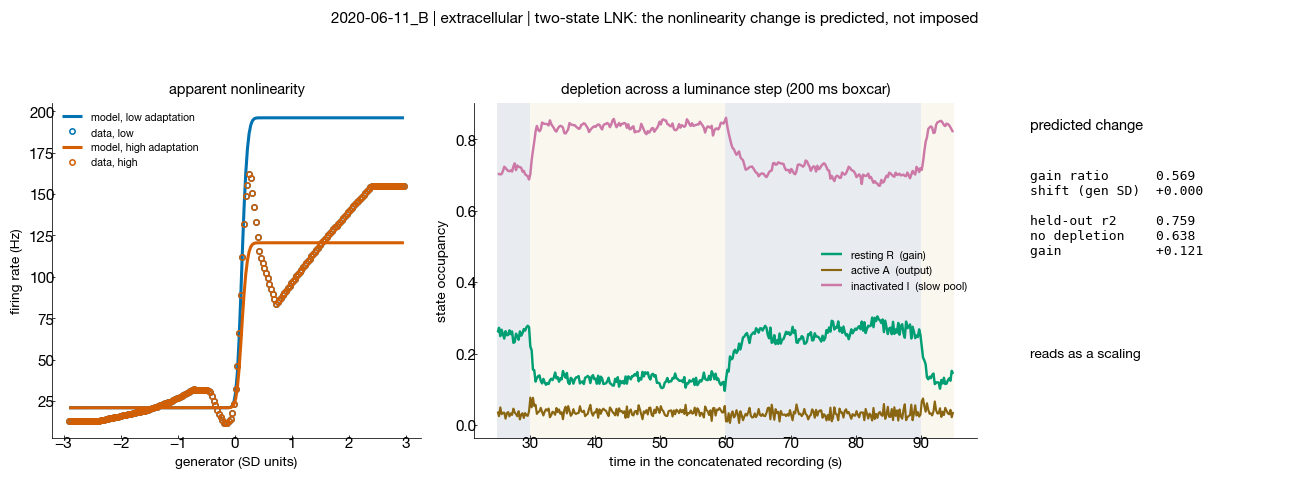

In [9]:
RUN_TWO_STATE = True     # set False to skip this section

TWO_STATE_DT_MS = 250.0   # block for the slow pool; error falls with it
TWO_STATE_RESTARTS = 2    # rate constants redrawn; the LN start is kept
TWO_STATE_TEST_FRACTION = 0.25

two_state_by_condition = {}
if RUN_TWO_STATE:
    for (rec_type, duration), reconstruction in reconstruction_by_condition.items():
        print(f'\n=== two-state LNK | {rec_type} | {duration / 1e3:g} s epochs ===')
        decode_analysis = reconstruction['analysis']
        model = vmn.fit_lnk_two_state(
            decode_analysis, state_dt_ms=TWO_STATE_DT_MS,
            n_restarts=TWO_STATE_RESTARTS,
            test_fraction=TWO_STATE_TEST_FRACTION, verbose=True)
        curves = vmn.apparent_nonlinearity(decode_analysis, model)
        print('\nemergent nonlinearity change:',
              {key: (round(value, 4) if isinstance(value, float) else value)
               for key, value in vmn.describe_apparent_change(curves).items()})
        figure = vmn.plot_apparent_nonlinearity(
            decode_analysis, model, curves)
        two_state_by_condition[(rec_type, duration)] = {
            'model': model, 'curves': curves, 'figure': figure}
else:
    print('skipped (RUN_TWO_STATE = False)')


## 7. Population analysis from saved cells

This section is standalone after imports: it reads only the compact HDF5 records and never
opens raw recordings or runs an LNK fit. Recording type remains a grouping column, so spike rate
and current are never averaged together. Use `POP_REC_TYPES` to restrict the view, or leave it
as `None` to retain all automatically saved modes.

Every summary keeps `stim_seconds` as a grouping dimension, then collapses repeated rows within a
physical cell and computes population mean, SEM, and `n_cells`. Different epoch durations are never
averaged together, and epoch-rich cells do not carry extra weight.


In [ ]:
POP_REC_TYPES = None                 # None keeps all; or select extracellular/exc/inh
POP_CELL_TYPES = None                # e.g. ('OFF-parasol',); None keeps all

def select_population(frame):
    if frame.empty:
        return frame
    # Version-1 files predate duration separation and cannot safely enter
    # a temporal population average until that cell is rerun and resaved.
    keep = pd.to_numeric(frame.stim_seconds, errors='coerce').notna()
    if POP_REC_TYPES is not None:
        keep &= frame.rec_type.isin(POP_REC_TYPES)
    if POP_CELL_TYPES is not None:
        keep &= frame.cell_type.isin(POP_CELL_TYPES)
    return frame.loc[keep].copy()

saved_cells = vmn.load_condition_index()
legacy_count = int(saved_cells.stim_seconds.isna().sum())
if legacy_count:
    print(f'{legacy_count} legacy save(s) lack epoch duration and are excluded; '
          'rerun §§2–5 to replace them with duration-specific records')
display(select_population(saved_cells)[
    ['date', 'cell_label', 'cell_type', 'rec_type', 'stim_seconds',
     'n_epochs_total', 'rig', 'led', 'led_ndfs', 'optical_density', 'n_blocks']])

mean_rows = select_population(vmn.load_population_table('mean_response'))
mean_population = vmn.population_mean_sem(
    mean_rows, group_by=['cell_type', 'rec_type', 'stim_seconds',
                         'light_mean', 'time_s'],
    metrics=['mean'])
display(mean_population.round(3))
mean_population_figures = {
    duration: vmn.plot_population_metrics(
        block, x='time_s', metrics=['mean'], hue='light_mean')
    for duration, block in mean_population.groupby('stim_seconds')}

condition_rows = select_population(vmn.load_population_table('condition_summary'))
condition_population = vmn.population_mean_sem(
    condition_rows, group_by=['cell_type', 'rec_type', 'stim_seconds',
                              'lightMean'],
    metrics=['r2', 'time_to_peak_ms', 'biphasic_index'])
display(condition_population.round(3))
condition_population_figures = {
    duration: vmn.plot_population_metrics(
        block, x='lightMean',
        metrics=['r2', 'time_to_peak_ms', 'biphasic_index'], hue='cell_type')
    for duration, block in condition_population.groupby('stim_seconds')}


### 7a. Population adaptation over time

Pool the temporal-LN metrics from §3 by epoch duration, window order, and light mean. Cells recorded
with the same duration and skip have aligned windows by construction; different durations remain
separate before `order` is compared.


In [ ]:
temporal_rows = select_population(vmn.load_population_table('temporal_summary'))
temporal_population = vmn.population_mean_sem(
    temporal_rows,
    group_by=['cell_type', 'rec_type', 'stim_seconds', 'lightMean', 'order'],
    metrics=['centre_s', 'r2', 'time_to_peak_ms', 'biphasic_index',
             'alpha', 'beta', 'gamma', 'epsilon'])
display(temporal_population.round(3))
temporal_population_figures = {
    duration: vmn.plot_population_metrics(
        block, x='order',
        metrics=['r2', 'time_to_peak_ms', 'biphasic_index'], hue='lightMean')
    for duration, block in temporal_population.groupby('stim_seconds')}


### 7b. Population stimulus reconstruction

Reproduce the §4 recovery and phase-asymmetry metrics across cells. The first table is one row
per decoder regime × light mean; the second compares the early and late transfer-function halves.


In [ ]:
reconstruction_rows = select_population(
    vmn.load_population_table('reconstruction_summary'))
reconstruction_population = vmn.population_mean_sem(
    reconstruction_rows,
    group_by=['cell_type', 'rec_type', 'stim_seconds', 'mode', 'lightMean'],
    metrics=['r_all_first', 'r_all_last', 'r_gain', 'r_asymmetry',
             'gain_asymmetry', 'nrmse_inc', 'nrmse_dec'])
display(reconstruction_population.round(3))
reconstruction_population_figures = {
    duration: vmn.plot_population_metrics(
        block, x='lightMean',
        metrics=['r_gain', 'r_asymmetry', 'gain_asymmetry'], hue='mode')
    for duration, block in reconstruction_population.groupby('stim_seconds')}

early_late_rows = select_population(vmn.load_population_table('early_late'))
early_late_population = vmn.population_mean_sem(
    early_late_rows,
    group_by=['cell_type', 'rec_type', 'stim_seconds', 'mode', 'lightMean', 'half'],
    metrics=['gain_increment', 'gain_decrement', 'gain_asymmetry',
             'r_increment', 'r_decrement', 'r_asymmetry'])
display(early_late_population.round(3))


## 8. LED light level

The LED's own neutral density filters set the light level. A `FilterWheel` NDF is real — the
wheel exists on the rig — but it is **not in the LED's path**, so it must not be added to this
stimulus's attenuation. `led_attenuation` returns it separately with `wheel_ignored` set, rather
than dropping it silently, because the same metadata is correct for a Stage protocol and wrong
here.

A filter with no entry in the rig's LED table leaves `optical_density` blank and is named in
`unknown_tokens`, so an unknown filter cannot masquerade as no attenuation.

In [10]:
light = vmn.light_level_table(protocol_blocks, show=True)

sc.scroll_table(
    light[['exp_name', 'rig', 'led', 'led_ndfs', 'optical_density', 'attenuation',
           'wheel_tokens_ignored', 'unknown_tokens', 'n_blocks']].round(4),
    height=340, num_cols=('optical_density', 'attenuation', 'n_blocks'))

46 experiment x LED combinations | 2 list an FW filter that is not in the LED path (stripped, named in wheel_tokens_ignored)
7 with filters missing from the rig LED table: ['E7', 'G5']


exp_name,rig,led,led_ndfs,optical_density,attenuation,wheel_tokens_ignored,unknown_tokens,n_blocks
2020-06-11_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-16_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-23_B,two_photon,UV LED,(none),0.0,1.0,,,3
2020-07-13_G,shared_two_photon,Red LED,(none),0.0,1.0,,,3
2020-07-14_G,shared_two_photon,Red LED,(none),0.0,1.0,,,8
2020-07-29_G,shared_two_photon,UV LED,(none),0.0,1.0,,,18
2020-08-11_G,shared_two_photon,UV LED,(none),0.0,1.0,,,17
2020-08-25_G,shared_two_photon,UV LED,(none),0.0,1.0,,,8
2020-08-25_G_scotopic,shared_two_photon,UV LED,"G7, G8, G9",4.07,0.0001,,,4
2020-10-20_G,shared_two_photon,UV LED,(none),0.0,1.0,,,6


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:340px"><table><thead><tr><th>exp_name</th><th>rig</th><th>led</th><th>led_ndfs</th><th>optical_density</th><th>attenuation</th><th>wheel_tokens_ignored</th><th>unknown_tokens</th><th>n_blocks</th></tr></thead><tbody><tr><td>2020-06-11_B</td><td>t

## 9. The saved MATLAB summary, for comparison

`matlabSummary/rodVariableMeanNoise.mat` holds the 53 cells the MATLAB analysis was run on,
with its own fitted LN models. It is **not** an input to anything above — the analysis here runs
from the recordings. It is kept so the Python population summary can be compared against the
MATLAB's once there is one.

One thing to know when matching them up: the saved `expDate` is **two days early**, across the
board. `vmn.resolve_roster_files` applies that correction and confirms each cell by label
(case-sensitively) and type; `vmn.SAVED_DATE_OFFSET_DAYS` is the constant. That is only needed
for the comparison, so it is not run here.

In [11]:
roster = vmn.load_summary(show=True)

sc.scroll_table(
    roster[['index', 'exp_date', 'cell_label', 'cell_type', 'rec_type',
            'epoch_len_ms', 'tau_low', 'tau_high', 'is_example']].round(2),
    height=300, num_cols=('index', 'epoch_len_ms', 'tau_low', 'tau_high'))

print(f'\nsaved dates are {vmn.SAVED_DATE_OFFSET_DAYS} days early; '
      f'vmn.resolve_roster_files() corrects and confirms them when needed.')

53 saved cells | 16 dates | 15 rows in duplicated groups
rec_type   exc  extracellular
cell_type                    
OnMidget    11             10
OnParasol   14             18


index,exp_date,cell_label,cell_type,rec_type,epoch_len_ms,tau_low,tau_high,is_example
0,2020/07/27,cell5,OnParasol,extracellular,60000.0,11.87,15.94,False
1,2020/08/23,cell3,OnParasol,extracellular,55000.0,10.59,14.76,True
2,2020/08/23,cell6,OnParasol,extracellular,56000.0,9.07,0.05,True
3,2020/08/23,cell7,OnParasol,extracellular,60000.0,7.33,25909.59,True
4,2020/08/09,cell1,OnMidget,extracellular,60000.0,7.38,12.81,False
5,2020/08/09,cell3,OnParasol,extracellular,50000.0,9.54,12.29,False
6,2020/08/23,cell4,OnMidget,extracellular,55000.0,16.2,14.03,False
7,2021/04/25,cell1,OnParasol,extracellular,50000.0,7.0,7.65,True
8,2021/04/25,cell2,OnParasol,extracellular,50000.0,5.53,39.91,True
9,2021/04/25,cell3,OnParasol,extracellular,50000.0,6.06,28.17,True



saved dates are 2 days early; vmn.resolve_roster_files() corrects and confirms them when needed.
